In [3]:
#Import all the necessary modules
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
df = pd.read_csv('parkinsons.data')

### Eyeball raw-data to understand attributes and its types, number of rows/columns and missing values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [6]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [7]:
df['status'].value_counts()

1    147
0     48
Name: status, dtype: int64

In [8]:
## Observation - 
# In the given dataset out of 195 patients, 147 patients are reported to have Parkinson's disease.
# There are no missing values in the dataset.

### Univariate & Bi-variate analysis 

In [9]:
#Describe function provides insight to basic statistics (central tendency, spread, min/max values)
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [10]:
# Corr function provides correlation (mutual association) between any two variables 
df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383535,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.166136,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.380200,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.278220,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.338653,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.266668,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.288698,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.266646,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.367430,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.350697,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001F95F14EAC8>,
      dtype=object)

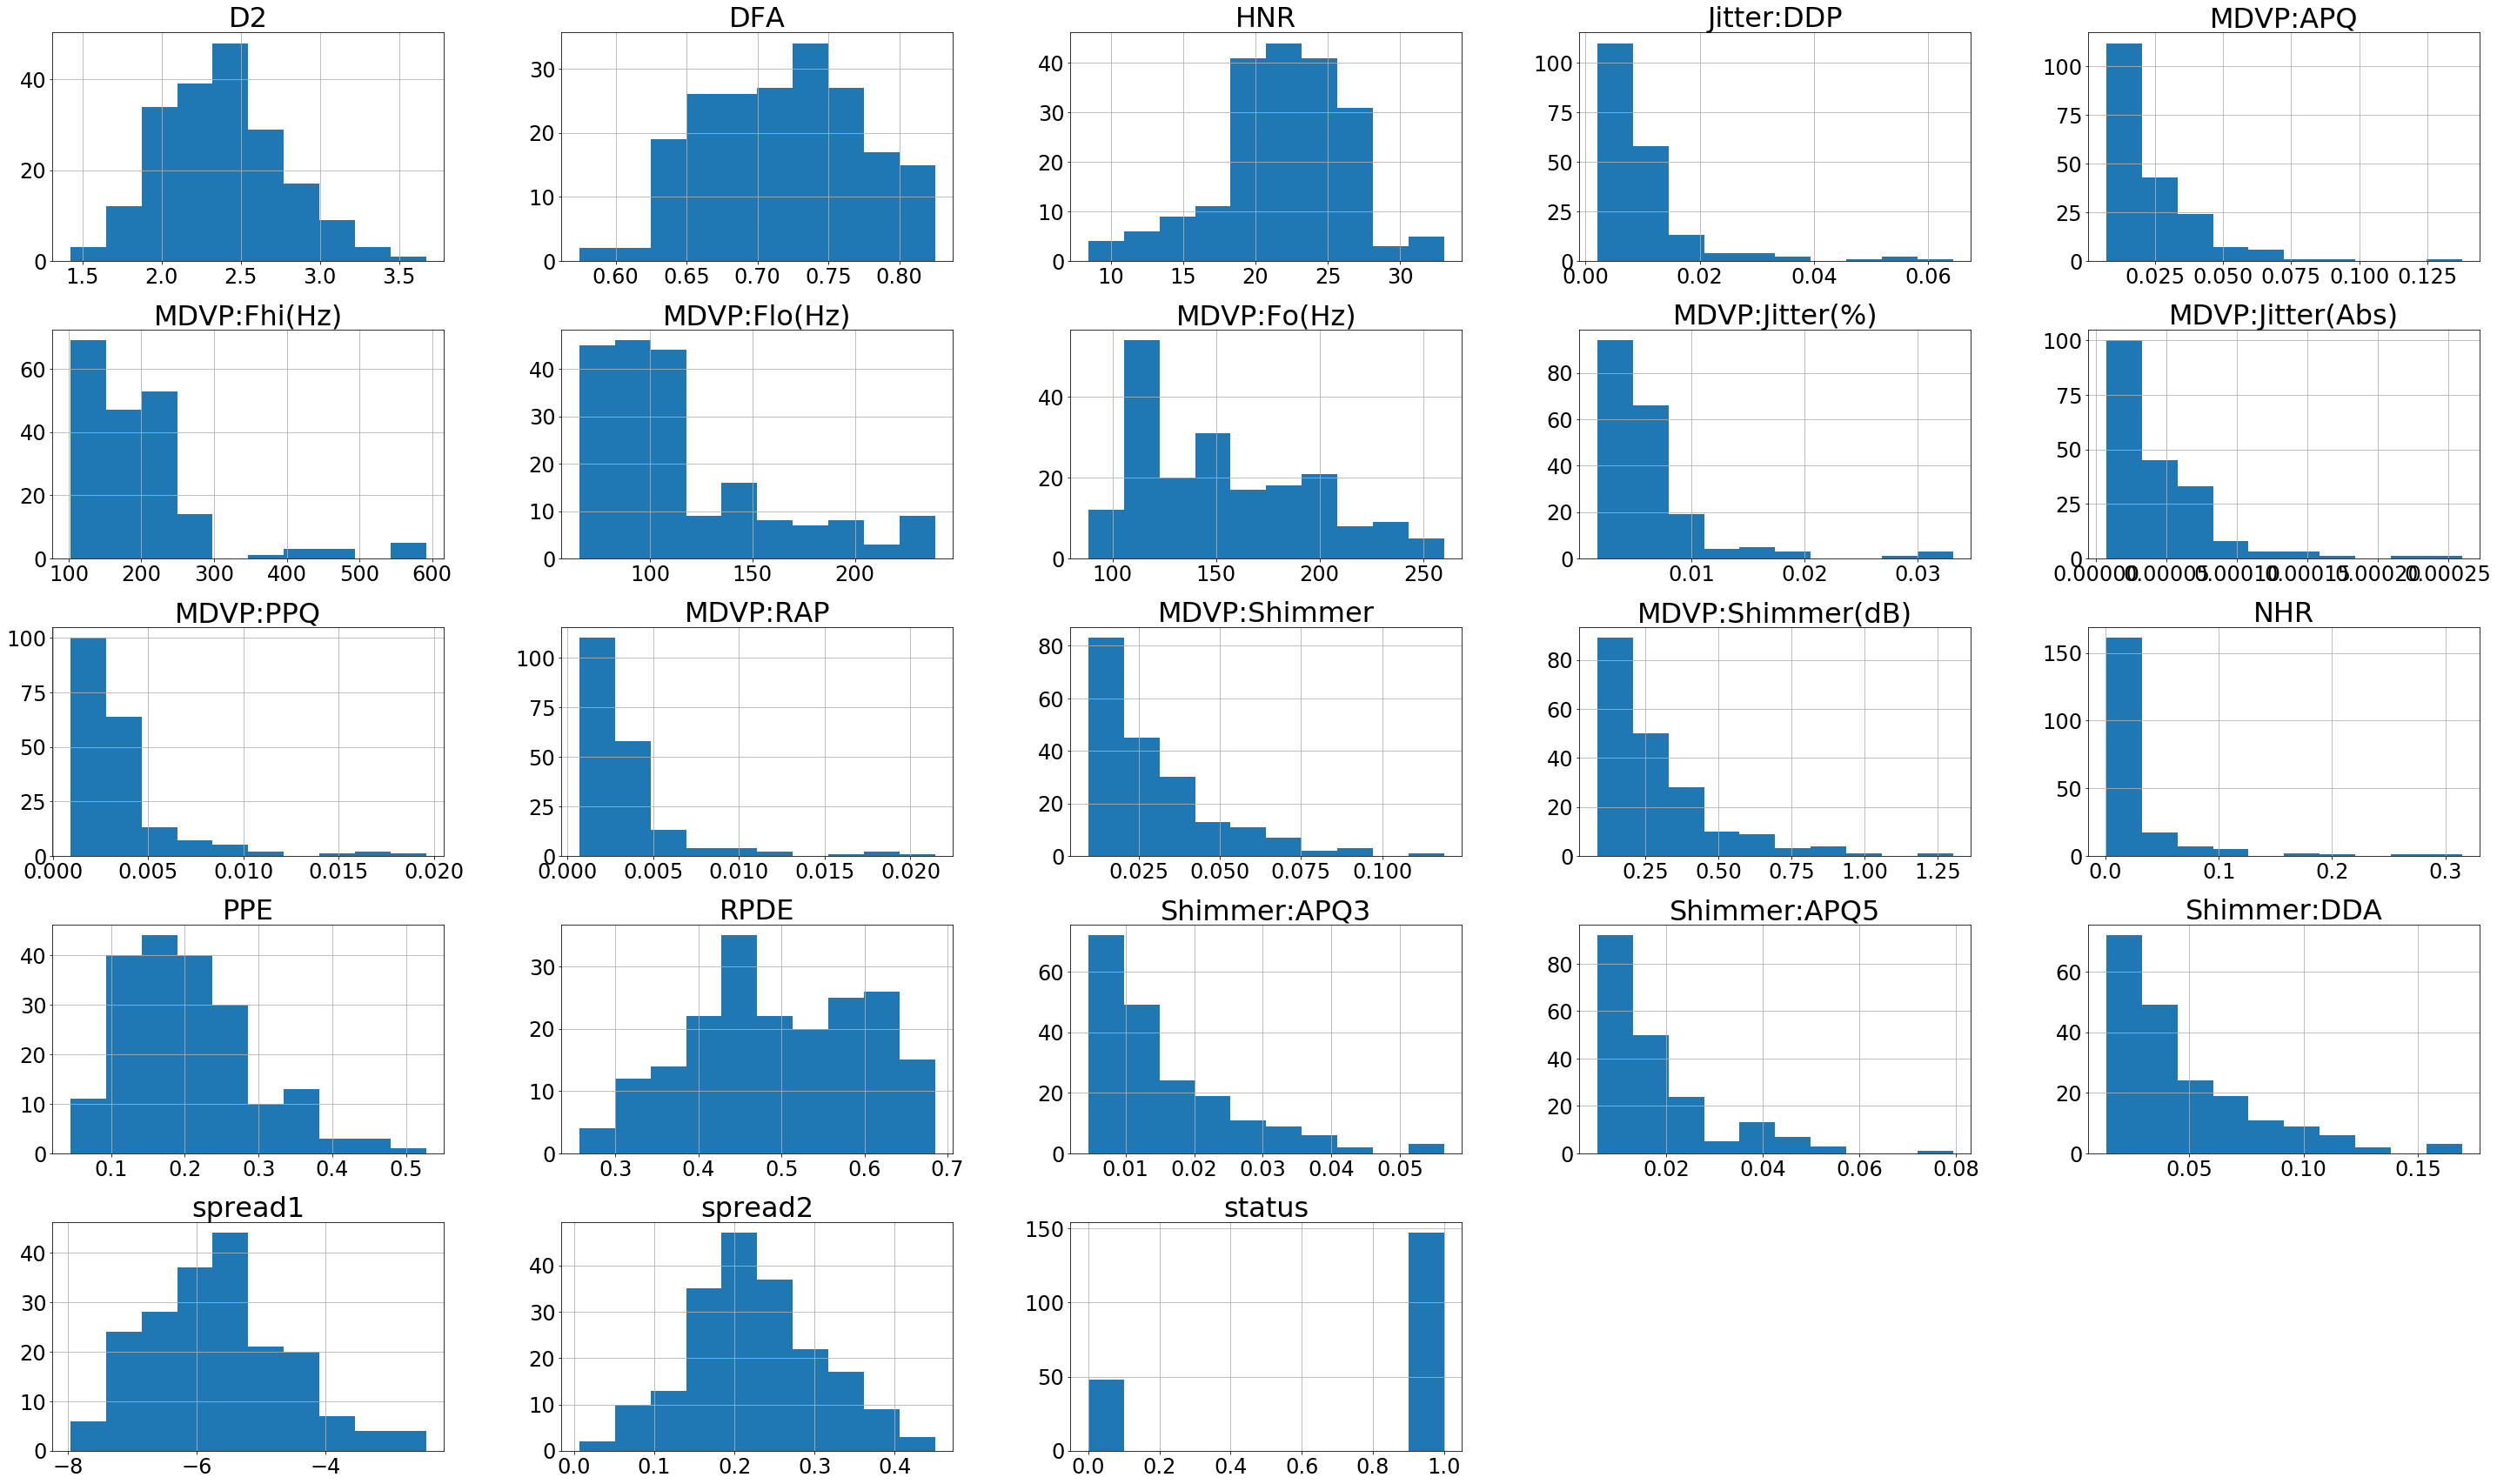

In [11]:
# importing ploting libraries
import matplotlib.pyplot as plt   
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
params = {'axes.titlesize':'32',
          'xtick.labelsize':'24',
          'ytick.labelsize':'24'}
plt.rcParams.update(params)
df.hist(figsize=(50, 30))

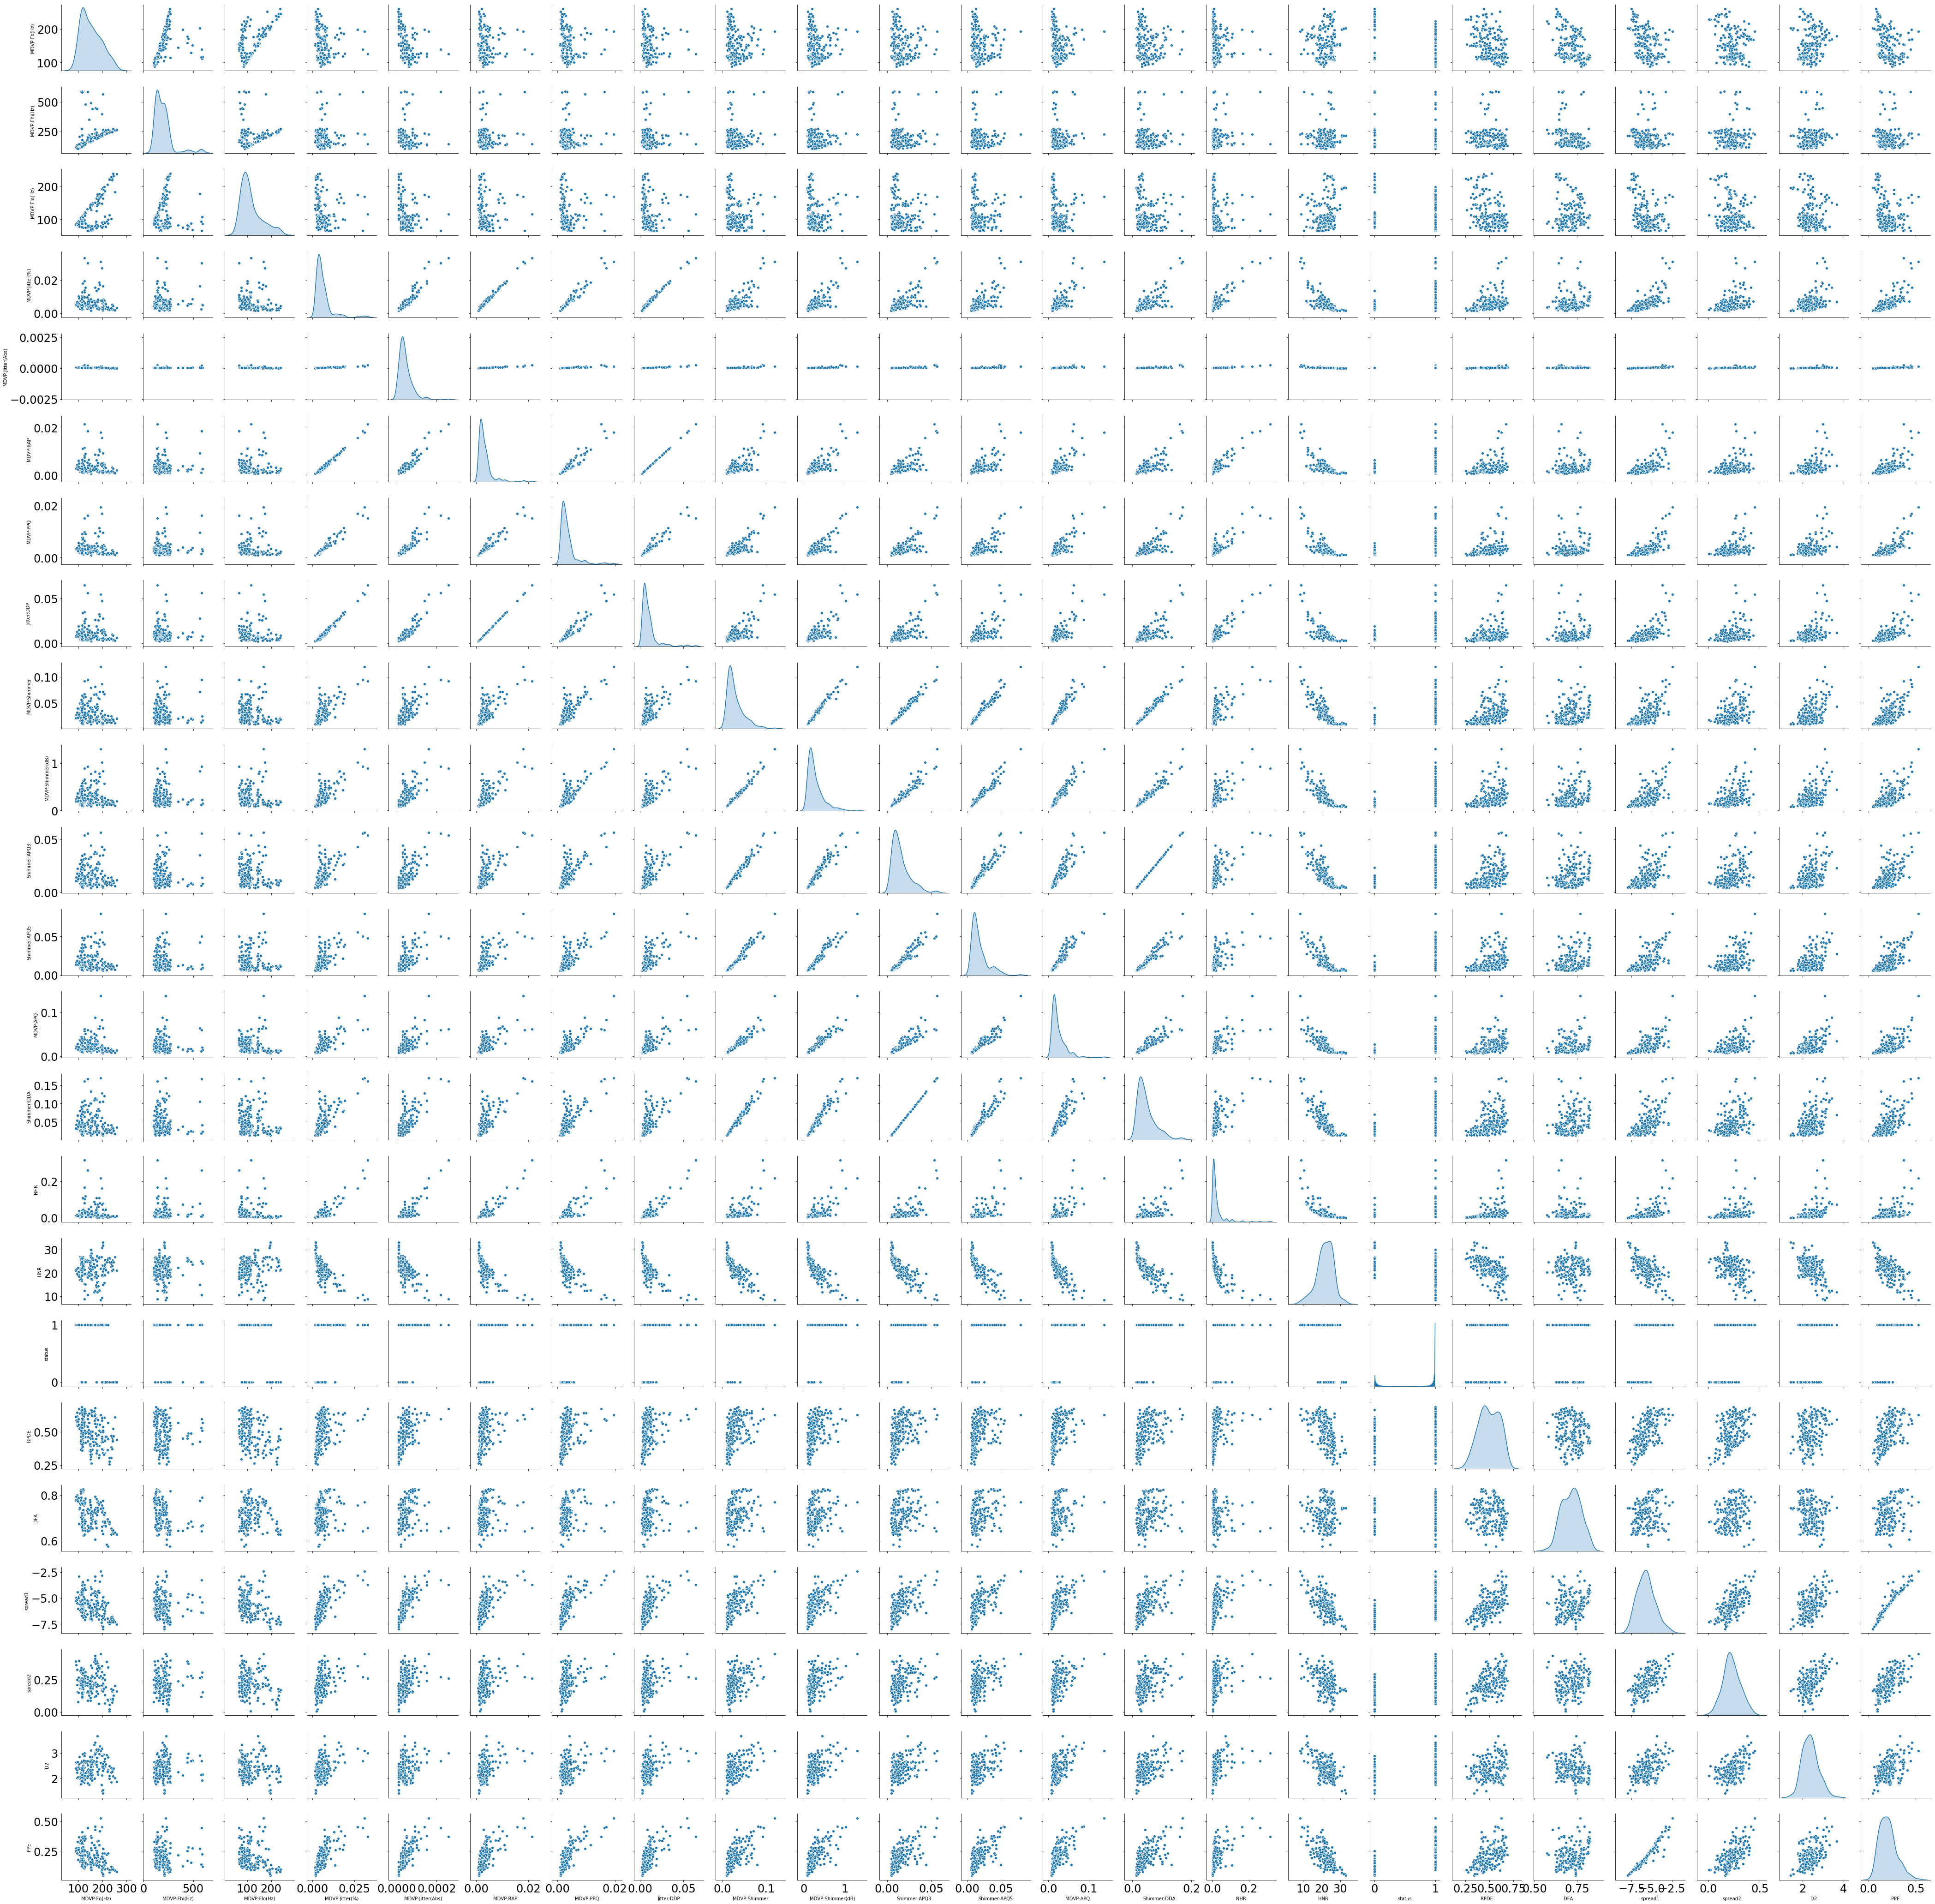

In [12]:
sns.pairplot(df, diag_kind='kde')

In [13]:
## Observations
# Patients with Parkinson's Disease have relatively low vocal fundamental frequencies MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz) 
# compared to healthy patients.
# Patients with Parkinson's Disease have relatively high variations for several measures of variation in fundamental frequency
# (MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP) and 
# several measures of variation in amplitude (MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA) 
# compared to healthy patients.
# HNR (Harmonic to Noise ratio ) is high for healthy patients when compared to patients with Parkinson's Disease 
# whereas NHR (Noise to Harmonic ratio) is low in healthy patients.
# The two nonlinear dynamical complexity measures (RPDE,D2) and three nonlinear measures of 
# fundamental frequency variation (spread1,spread2,PPE) are comparitively high for patients with Parkinson's Disease.

### Split dataset into train and test

In [14]:
X = df.drop(["status","name"], axis=1)
y = df["status"]
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Create the model using “entropy” method and fit it to training data

In [15]:
model=DecisionTreeClassifier(criterion='entropy',random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

### Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. 

In [16]:
y_predict=model.predict(X_test)

In [17]:
model_accuracy = accuracy_score(y_test, y_predict)
print("Accuracy achieved is", model_accuracy)

Accuracy achieved is 0.8813559322033898


In [18]:
cmat = pd.crosstab(y_predict, y_test, rownames=['Predictions'], colnames=['Actuals'])
print('*******Crosstab of Predictions vs Actuals for Test set ******')
print(cmat)

*******Crosstab of Predictions vs Actuals for Test set ******
Actuals       0   1
Predictions        
0            11   6
1             1  41


In [19]:
# Observations based on crosstab.
# Within test set containing total of 59 patient records, the above model 
#    - Correctly predicted 41 patients having Parkinson's disease out of actual 47 patients with disease
#      and incorrectly predicted 6 patients as healthy.
#    - Correctly Predicted 11 patients to be healthy out of actual 12 healthy patients
#      and incorrectly predicted one healthy patient as having the disease.

### Use regularization parameters of max_depth, min_sample_leaf to recreate the model.

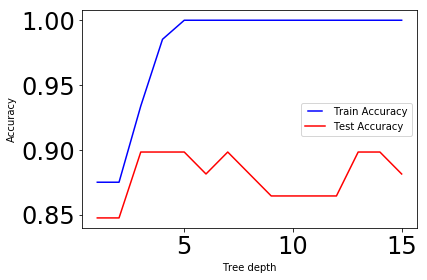

In [36]:
## Tuning max_depth parameter
max_depths = np.linspace(1, 15, 15, endpoint=True)
train_results = []
test_results = []
for max_depth in max_depths:
   dt = DecisionTreeClassifier(max_depth=max_depth)
   dt.fit(X_train, y_train)
   train_pred = dt.predict(X_train)
   train_accuracy = accuracy_score(y_train, train_pred)
   train_results.append(train_accuracy)
   y_pred = dt.predict(X_test)
   test_accuracy = accuracy_score(y_test, y_pred)
   test_results.append(test_accuracy)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(max_depths, train_results,"b", label="Train Accuracy")
line2, = plt.plot(max_depths, test_results,"r", label="Test Accuracy")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('Accuracy')
plt.xlabel('Tree depth')
plt.show()

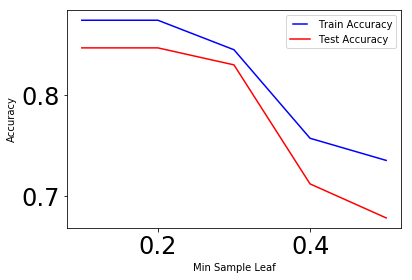

In [22]:
## Tuning min_sample_leaf parameter
min_samples_leafs = np.linspace(0.1, 0.5, 5, endpoint=True)
train_results = []
test_results = []
for min_samples_leaf in min_samples_leafs:
   dt = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf)
   dt.fit(X_train, y_train)
   train_pred = dt.predict(X_train)
   train_accuracy = accuracy_score(y_train, train_pred)
   train_results.append(train_accuracy)
   y_pred = dt.predict(X_test)
   test_accuracy = accuracy_score(y_test, y_pred)
   test_results.append(test_accuracy)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(min_samples_leafs, train_results,"b", label="Train Accuracy")
line2, = plt.plot(min_samples_leafs, test_results,"r", label="Test Accuracy")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('Accuracy')
plt.xlabel('Min Sample Leaf')
plt.show()

In [24]:
regmodel=DecisionTreeClassifier(criterion='entropy',random_state=0, max_depth=3,min_samples_leaf=2)
regmodel.fit(X_train,y_train)
y_predict=regmodel.predict(X_test)
regmodel_accuracy = accuracy_score(y_test, y_predict)
print("Accuracy achieved before tuning max_depth and min_sample_leaf - ", model_accuracy)
print("Accuracy achieved after tuning max_depth and min_sample_leaf - ", regmodel_accuracy)

Accuracy achieved before tuning max_depth and min_sample_leaf -  0.8813559322033898
Accuracy achieved after tuning max_depth and min_sample_leaf -  0.8983050847457628


In [25]:
## Observations
# As shown above in the Accuracy vs Max Depth plot, increasing tree depth may increase accuracy, but it could 
# result in overfitting on train data. In this dataset an optimal max_depth can be used as 3 without overfitting.
# As shown above in the Accuracy vs Min Sample Leaf plot, Increasing min_sample_leafs will result in underfitting of data
# due to the fact that the model will not have enough training on the data due to incresed number of samples at leaf level.
# In this dataset an optimal min_sample_leaf value can be set as 2 without underfitting.
# Regularization helps in determining good accuracy of the model without overfitting or underfitting of the model.

### Decision Tree using Random Forest

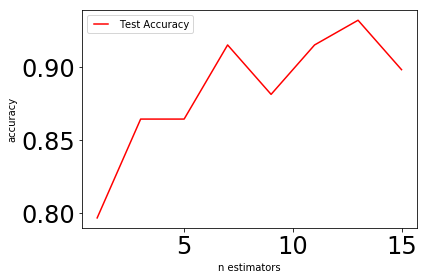

In [32]:
n_estimators = [1, 3, 5, 7, 9, 11, 13, 15] # Using odd n_estimator values from 1 to square-root of total N observations.
test_results = []
optimal_estimator = 1
optimal_accuracy = 0
for estimator in n_estimators:
   rf = RandomForestClassifier(n_estimators=estimator,criterion='entropy', n_jobs=-1)
   rf.fit(X_train, y_train)
   y_pred = rf.predict(X_test)
   test_accuracy = accuracy_score(y_test, y_pred)
   test_results.append(test_accuracy)
   if test_accuracy > optimal_accuracy :
    optimal_estimator = estimator
    optimal_accuracy = test_accuracy
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(n_estimators, test_results,"r", label="Test Accuracy")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('accuracy')
plt.xlabel('n estimators')
plt.show()

In [34]:
print("Optimal number of trees using Random Forest model for this dataset is ", optimal_estimator)
print(" and the best accuracy is ", optimal_accuracy)

Optimal number of trees using Random Forest model for this dataset is  13
 and the best accuracy is  0.9322033898305084
